# Analisi Componenti Connesse Bianche
Identificazione e visualizzazione di tutte le componenti bianche connesse in un'immagine binaria/grayscale.

**Librerie usate:** `opencv-python`, `numpy`, `matplotlib`


> **Nota:** se riesegui il notebook dopo modifiche, usa **Kernel → Restart & Run All** per evitare conflitti con variabili precedenti.

In [1]:
# Installazione dipendenze (eseguire solo se necessario)
# !pip install opencv-python-headless numpy matplotlib


## 1. Import e Configurazione

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
from pathlib import Path

# ─── PARAMETRI ───────────────────────────────────────────────────
IMAGE_PATH  = r"D:\PROGETTO MISURE\Dataset\005.jpg"  # percorso immagine
OUTPUT_DIR  = Path("output").resolve()                 # cartella output
THRESHOLD   = 35    # soglia binarizzazione (0–255)
MIN_AREA    = 5      # area minima in pixel (filtra rumore)
CONNECTIVITY = 8     # 4 = solo N/S/E/O  |  8 = anche diagonali
TOP_N        = 50    # quante componenti evidenziare nella viz
# ─────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✓ Configurazione completata")


✓ Configurazione completata


## 2. Caricamento e Binarizzazione

Dimensioni  : 1936 × 1216 px
Valori min/max nei pixel: 9 / 235
Pixel bianchi: 41526  (1.76% dell'immagine)


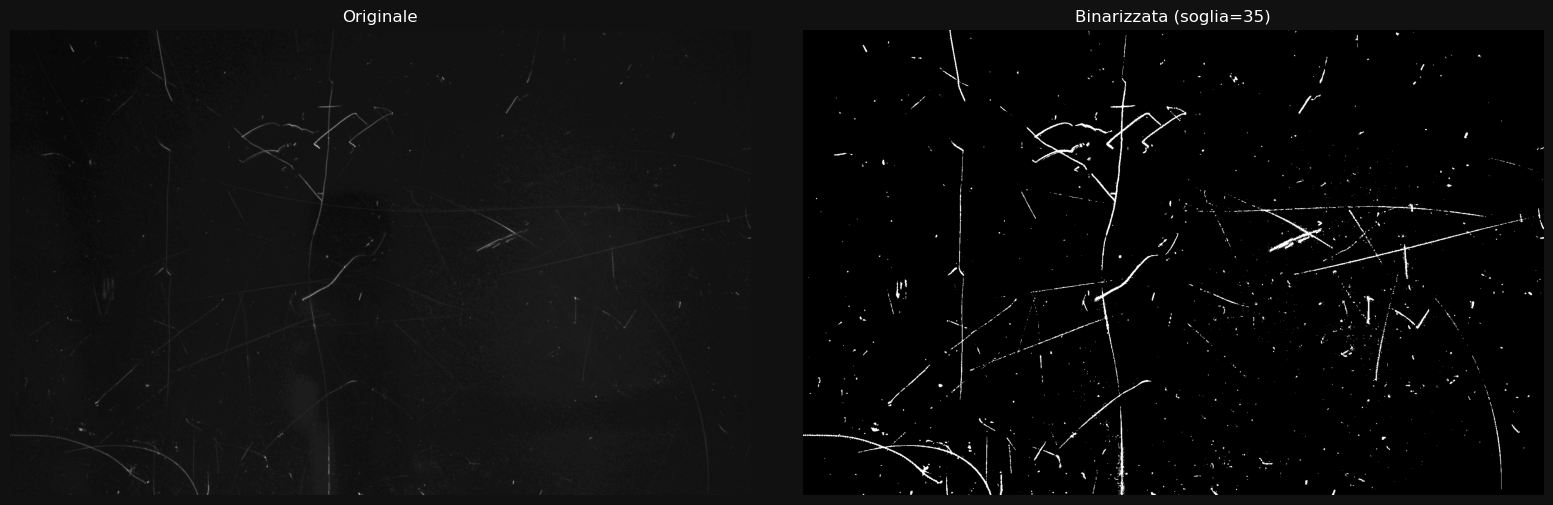

In [15]:
# Caricamento in scala di grigi
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_IMREAD_GRAYSCALE if False else cv2.IMREAD_GRAYSCALE)
assert img is not None, f"Immagine non trovata: {IMAGE_PATH}"

h, w = img.shape
print(f"Dimensioni  : {w} × {h} px")
print(f"Valori min/max nei pixel: {img.min()} / {img.max()}")

# Binarizzazione con soglia fissa
_, binary = cv2.threshold(img, THRESHOLD, 255, cv2.THRESH_BINARY)

white_px = np.sum(binary == 255)
print(f"Pixel bianchi: {white_px}  ({white_px / (h*w) * 100:.2f}% dell'immagine)")

# Anteprima
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#111')
axes[0].imshow(img, cmap='gray');  axes[0].set_title('Originale', color='w');  axes[0].axis('off')
axes[1].imshow(binary, cmap='gray'); axes[1].set_title(f'Binarizzata (soglia={THRESHOLD})', color='w'); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 3. Analisi delle Componenti Connesse

In [16]:
# Calcolo componenti connesse
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary, connectivity=CONNECTIVITY
)

# Raccolta dati (label 0 = sfondo, esclusa)
components = []
for i in range(1, num_labels):
    area = int(stats[i, cv2.CC_STAT_AREA])
    if area >= MIN_AREA:
        components.append({
            'id'    : i,
            'area'  : area,
            'x'     : int(stats[i, cv2.CC_STAT_LEFT]),
            'y'     : int(stats[i, cv2.CC_STAT_TOP]),
            'w'     : int(stats[i, cv2.CC_STAT_WIDTH]),
            'h'     : int(stats[i, cv2.CC_STAT_HEIGHT]),
            'cx'    : round(float(centroids[i][0]), 2),
            'cy'    : round(float(centroids[i][1]), 2),
            'ratio' : round(float(stats[i, cv2.CC_STAT_WIDTH]) /
                            max(float(stats[i, cv2.CC_STAT_HEIGHT]), 1), 3),
        })

components.sort(key=lambda x: x['area'], reverse=True)
areas = [c['area'] for c in components]

print(f"Componenti totali rilevate : {num_labels - 1}")
print(f"Componenti significative   : {len(components)}  (area ≥ {MIN_AREA} px)")
print(f"Pixel bianchi totali       : {sum(areas)}  ({sum(areas)/(h*w)*100:.2f}%)")
print(f"Area media                 : {np.mean(areas):.1f} px")
print(f"Area mediana               : {np.median(areas):.1f} px")
print(f"Area massima               : {max(areas)} px  (ID={components[0]['id']})")
print(f"Area minima                : {min(areas)} px")


Componenti totali rilevate : 1728
Componenti significative   : 783  (area ≥ 5 px)
Pixel bianchi totali       : 39730  (1.69%)
Area media                 : 50.7 px
Area mediana               : 12.0 px
Area massima               : 3488 px  (ID=57)
Area minima                : 5 px


## 4. Top componenti per area

In [17]:
print(f"{'ID':>5} | {'Area':>7} | {'X':>5} {'Y':>5} {'W':>5} {'H':>5} | {'Cx':>8} {'Cy':>8} | Ratio")
print("-" * 65)
for c in components[:20]:
    print(f"{c['id']:>5} | {c['area']:>7} | {c['x']:>5} {c['y']:>5} {c['w']:>5} {c['h']:>5} | "
          f"{c['cx']:>8.1f} {c['cy']:>8.1f} | {c['ratio']:.3f}")


   ID |    Area |     X     Y     W     H |       Cx       Cy | Ratio
-----------------------------------------------------------------
   57 |    3488 |   753   128   183   502 |    824.5    336.4 | 0.365
 1453 |    3179 |    10  1057   482   159 |    289.9   1115.8 | 3.031
  358 |    2405 |  1152   469   226   113 |   1279.9    533.6 | 2.000
  454 |    1948 |  1332   511   487   141 |   1566.2    581.2 | 3.454
  119 |    1815 |   584   244   159   124 |    660.7    304.1 | 1.282
  576 |    1783 |   762   589   166   280 |    819.9    697.0 | 0.593
 1362 |    1148 |   824   984    16   232 |    832.2   1124.1 | 0.069
   92 |     793 |   885   204   117   111 |    938.9    257.3 | 1.054
 1251 |     743 |   720   916   190   128 |    811.2    971.9 | 1.484
    1 |     693 |   382     0    42   189 |    399.9     97.0 | 0.222
  784 |     579 |   403   704    21   264 |    414.0    842.0 | 0.080
  334 |     558 |  1445   456   201    21 |   1560.9    465.4 | 9.571
  120 |     469 |   711 

## 5. Visualizzazione

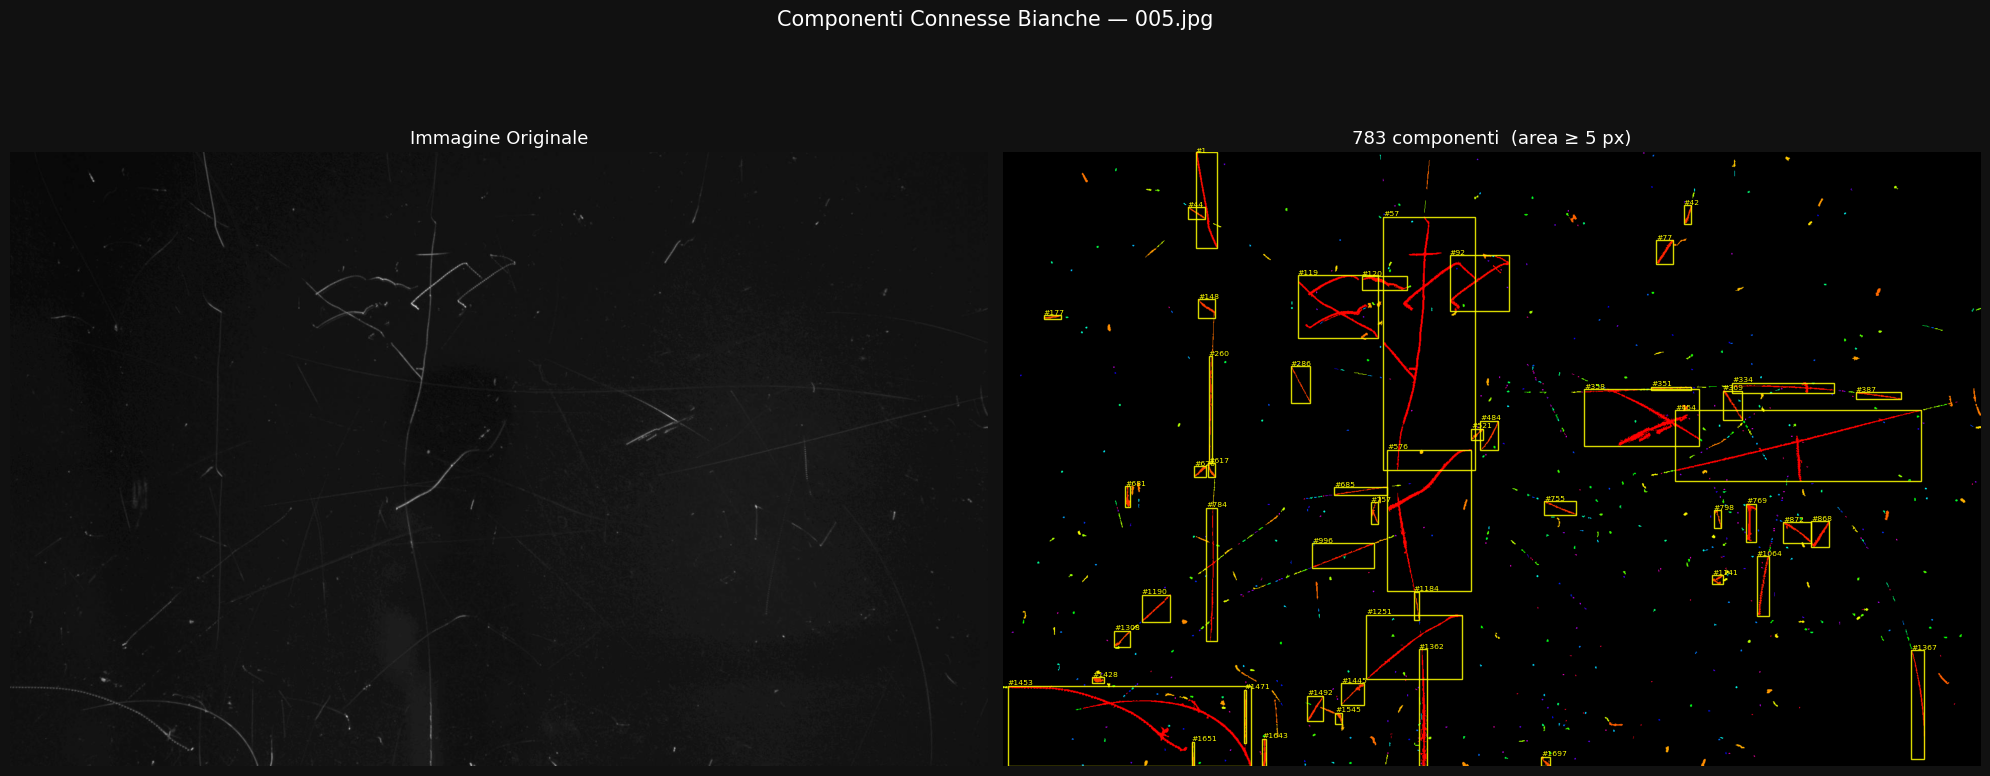

✓ Salvata: D:\PROGETTO MISURE\output\components_analysis.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor='#111')

# Sinistra: originale
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Immagine Originale', color='white', fontsize=13)
axes[0].axis('off')

# Destra: componenti colorate
colored = np.zeros((h, w, 3), dtype=np.uint8)
palette = plt.cm.hsv(np.linspace(0, 1, max(len(components), 1)))

for idx, c in enumerate(components):
    col = palette[idx]
    mask = labels == c['id']
    colored[mask] = [int(col[0]*255), int(col[1]*255), int(col[2]*255)]

axes[1].imshow(colored)
axes[1].set_title(f'{len(components)} componenti  (area ≥ {MIN_AREA} px)', color='white', fontsize=13)
axes[1].axis('off')

# Bounding box sulle prime TOP_N componenti
for c in components[:TOP_N]:
    rect = mpatches.Rectangle(
        (c['x'], c['y']), c['w'], c['h'],
        linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.85
    )
    axes[1].add_patch(rect)
    axes[1].text(c['x'], max(c['y']-2, 0), f"#{c['id']}", color='yellow', fontsize=5.5)

fig.suptitle(f"Componenti Connesse Bianche — {Path(IMAGE_PATH).name}", color='white', fontsize=15)
plt.tight_layout()

out_path = OUTPUT_DIR / "components_analysis.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#111', edgecolor='none')
plt.show()
print(f"✓ Salvata: {out_path}")


## 6. Distribuzione delle Aree

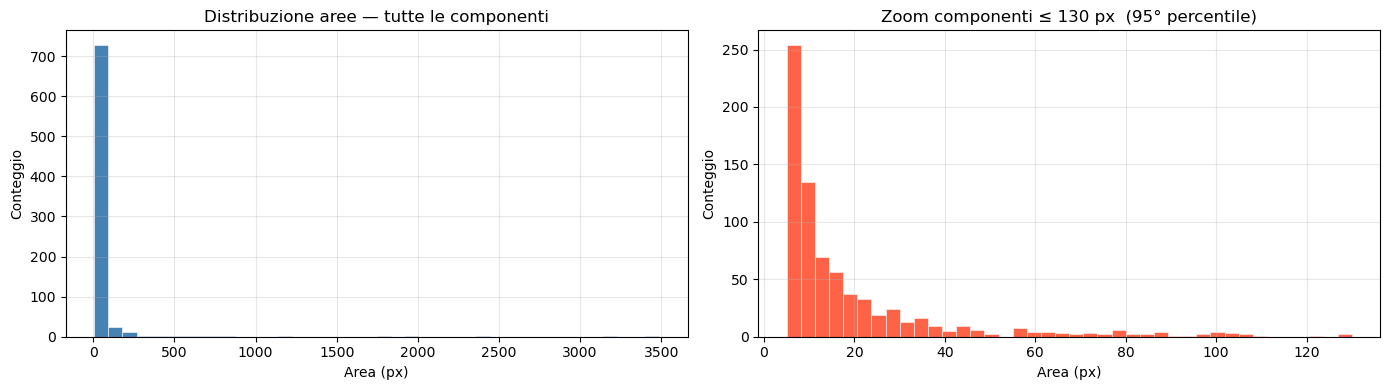

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Istogramma completo
axes[0].hist(areas, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Area (px)'); axes[0].set_ylabel('Conteggio')
axes[0].set_title('Distribuzione aree — tutte le componenti')
axes[0].grid(alpha=0.3)

# Zoom sulle piccole (< percentile 95)
p95 = int(np.percentile(areas, 95))
small_areas = [a for a in areas if a <= p95]
axes[1].hist(small_areas, bins=40, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Area (px)'); axes[1].set_ylabel('Conteggio')
axes[1].set_title(f'Zoom componenti ≤ {p95} px  (95° percentile)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7. Export CSV

In [20]:
csv_path = OUTPUT_DIR / "components_data.csv"
fieldnames = ['id', 'area', 'x', 'y', 'w', 'h', 'cx', 'cy', 'ratio']

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(components)

print(f"✓ CSV salvato: {csv_path}  ({len(components)} righe)")


✓ CSV salvato: D:\PROGETTO MISURE\output\components_data.csv  (783 righe)


## 8. Ricostruzione linee con HoughLinesP

`cv2.HoughLinesP` (Hough probabilistico) collega segmenti vicini e collineari,
trattando come un'unica linea i graffi che le componenti connesse avevano spezzato in più blob.

**Parametri chiave da calibrare:**

| Parametro | Significato | Valore consigliato |
|-----------|-------------|-------------------|
| `rho` | risoluzione in pixel della griglia | 1 |
| `theta` | risoluzione angolare (radianti) | π/180 (= 1°) |
| `threshold` | voti minimi per accettare una linea | 30–80 |
| `minLineLength` | lunghezza minima del segmento (px) | 20–50 |
| `maxLineGap` | gap massimo tra due segmenti da unire (px) | 10–30 |


In [30]:
# ─── PARAMETRI HOUGH ────────────────────────────────────────────
RHO           = 1           # risoluzione griglia (px)
THETA         = np.pi / 180 # risoluzione angolare (1°)
THRESHOLD     = 20          # voti minimi per accettare una linea
MIN_LINE_LEN  = 10          # lunghezza minima segmento (px)
MAX_LINE_GAP  = 20          # gap massimo tra segmenti da unire (px)
# ────────────────────────────────────────────────────────────────


Linee rilevate: 1065


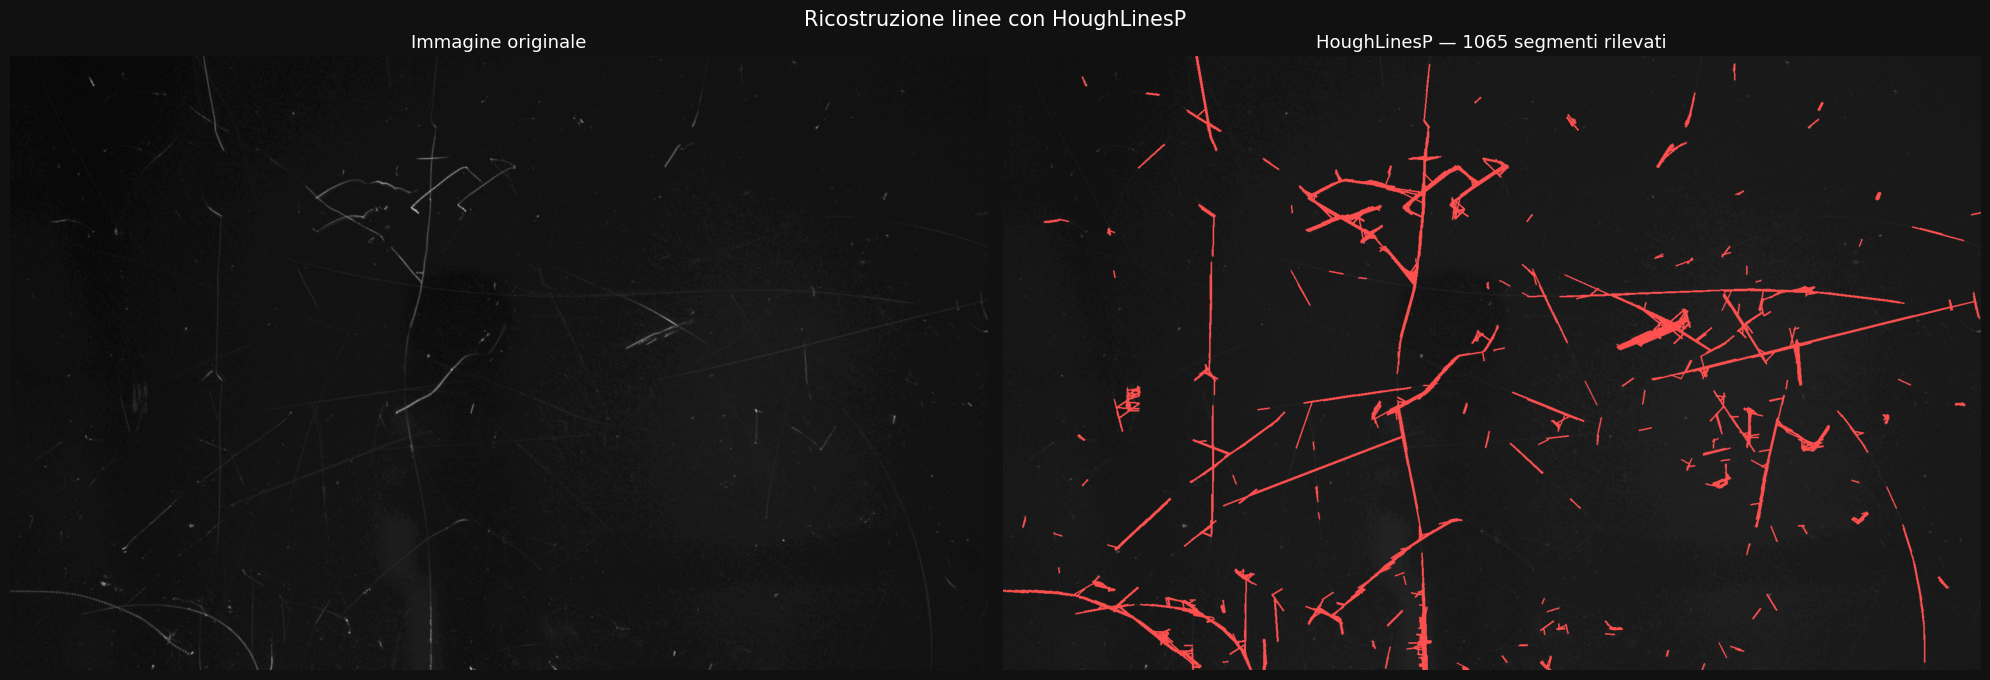

✓ Salvata: D:\PROGETTO MISURE\output\hough_lines.png


In [31]:
# Rilevamento linee
lines = cv2.HoughLinesP(
    binary,
    rho          = RHO,
    theta        = THETA,
    threshold    = THRESHOLD,
    minLineLength= MIN_LINE_LEN,
    maxLineGap   = MAX_LINE_GAP,
)

n_lines = len(lines) if lines is not None else 0
print(f"Linee rilevate: {n_lines}")

# Disegna le linee sull'immagine originale (copia a colori)
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
if lines is not None:
    for seg in lines:
        x1, y1, x2, y2 = seg[0]
        cv2.line(overlay, (x1, y1), (x2, y2), (255, 80, 80), 2)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor='#111')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Immagine originale', color='white', fontsize=13)
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'HoughLinesP — {n_lines} segmenti rilevati', color='white', fontsize=13)
axes[1].axis('off')

fig.suptitle('Ricostruzione linee con HoughLinesP', color='white', fontsize=15)
plt.tight_layout()

out_path = OUTPUT_DIR / 'hough_lines.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#111', edgecolor='none')
plt.show()
print(f"✓ Salvata: {out_path}")


Lunghezza media  : 60.7 px
Lunghezza mediana: 40.0 px
Segmento più lungo: 555.4 px


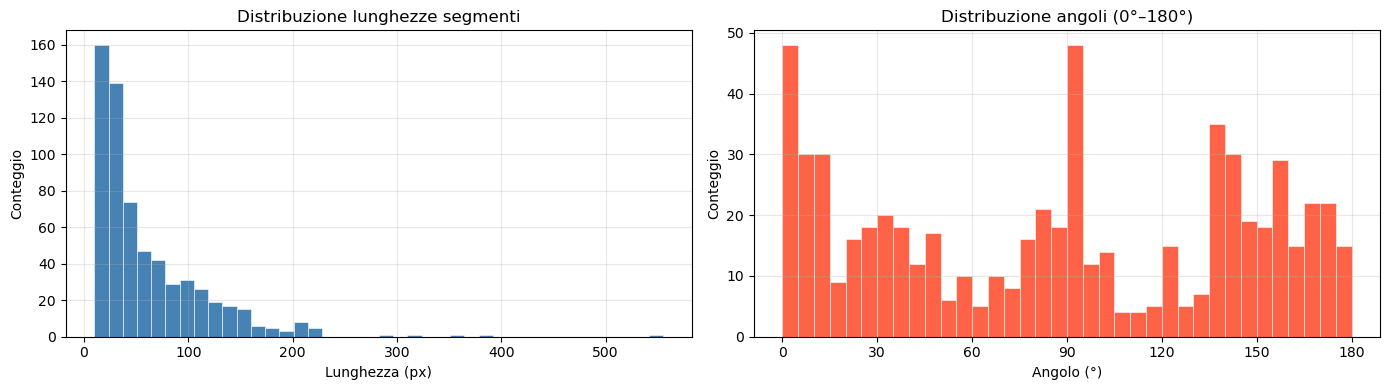

In [28]:
if lines is not None:
    lengths = []
    angles  = []
    for seg in lines:
        x1, y1, x2, y2 = seg[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        angle  = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
        lengths.append(length)
        angles.append(angle)

    print(f"Lunghezza media  : {np.mean(lengths):.1f} px")
    print(f"Lunghezza mediana: {np.median(lengths):.1f} px")
    print(f"Segmento più lungo: {max(lengths):.1f} px")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[0].set_xlabel('Lunghezza (px)')
    axes[0].set_ylabel('Conteggio')
    axes[0].set_title('Distribuzione lunghezze segmenti')
    axes[0].grid(alpha=0.3)

    axes[1].hist(angles, bins=36, range=(0, 180), color='tomato', edgecolor='white', linewidth=0.4)
    axes[1].set_xlabel('Angolo (°)')
    axes[1].set_ylabel('Conteggio')
    axes[1].set_title('Distribuzione angoli (0°–180°)')
    axes[1].set_xticks(range(0, 181, 30))
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Nessuna linea rilevata — prova ad abbassare THRESHOLD o MIN_LINE_LEN")


In [29]:
# Export CSV segmenti Hough
if lines is not None:
    hough_csv = OUTPUT_DIR / 'hough_lines.csv'
    with open(hough_csv, 'w', newline='') as f:
        import csv
        writer = csv.writer(f)
        writer.writerow(['x1','y1','x2','y2','length','angle_deg'])
        for seg in lines:
            x1,y1,x2,y2 = seg[0]
            length = round(np.sqrt((x2-x1)**2+(y2-y1)**2), 2)
            angle  = round(np.degrees(np.arctan2(y2-y1, x2-x1)) % 180, 2)
            writer.writerow([x1,y1,x2,y2,length,angle])
    print(f"✓ CSV Hough salvato: {hough_csv}  ({len(lines)} righe)")


✓ CSV Hough salvato: D:\PROGETTO MISURE\output\hough_lines.csv  (631 righe)
